# Cuando MASE y CRPS no coinciden

## Comparación práctica de modelos fundacionales de series de tiempo

## ¿Qué es TimeCopilot?

[TimeCopilot](https://timecopilot.dev) es el primer framework open-source de forecasting agéntico que combina múltiples **Time Series Foundation Models (TSFMs)** con **Large Language Models (LLMs)** a través de una sola API unificada.

TimeCopilot automatiza el pipeline de forecasting: análisis de features, selección de modelos, validación cruzada y generación de pronósticos, proporcionando explicaciones en lenguaje natural y soportando consultas directas sobre el futuro.

Resultados en el benchmark a gran escala [GIFT-Eval](https://huggingface.co/spaces/Salesforce/GIFT-Eval) muestran que TimeCopilot logra rendimiento **estado del arte** en forecasting probabilístico a bajo costo.

Referencia: [Garza & Rosillo, 2025. *TimeCopilot*. NeurIPS 2025 Workshop on Recent Advances in Time Series Foundation Models.](https://arxiv.org/abs/2509.00616)

## El Problema

**Mismos datos, mismos modelos, distintos ganadores.**

| Métrica | Mejor modelo | Peor modelo fundacional |
|---|---|---|
| MASE (precisión puntual) | Chronos (0.985) | Moirai (2.430) |
| Scaled CRPS (probabilístico) | TimesFM 2.0 (0.260) | Moirai (0.616) |

La pregunta no es *cuál modelo es mejor*.

La pregunta es: **¿qué penaliza más tu caso de uso — estimaciones puntuales sesgadas o intervalos mal calibrados?**

## Agenda

| Ejercicio | Tema | Tiempo |
|---|---|---|
| 1 | **Setup y Baselines** — Cargar datos, configurar 6 modelos, verificar el pipeline | ~10 min |
| 2 | **Validación Cruzada** — Generar pronósticos, inspeccionar la estructura de salida | ~15 min |
| 3 | **Análisis de Métricas** — Evaluar con MASE + CRPS, analizar dónde divergen los rankings | ~25 min |
| 4 | **Stress Test** — Cambiar horizontes, desglose por serie, probar con datos propios | ~25 min |

---

# Ejercicio 1: Setup y Baselines

*~10 minutos*

1. Cargar datos financieros (tipos de cambio) desde FRED, verificar esquema
2. Configurar los 6 modelos en un solo forecaster
3. Verificación rápida: graficar series, confirmar inferencia de frecuencia

### Instalación

In [ ]:
!uv pip install timecopilot

### Importar librerías

In [4]:
import pandas as pd

from timecopilot import TimeCopilotForecaster

### Cargar datos financieros desde FRED

Descargamos tipos de cambio diarios de la [Federal Reserve Economic Data (FRED)](https://fred.stlouisfed.org/):
- **USD/MXN** — Peso mexicano por dólar (relevante para operaciones en México)
- **EUR/USD** — Dólares por euro (mercado europeo)
- **USD/JPY** — Yenes por dólar (mercado asiático)
- **USD/GBP** — Dólares por libra esterlina (mercado UK)
- **USD/BRL** — Reales brasileños por dólar (mercado Latam)

TimeCopilot requiere un DataFrame con columnas `unique_id`, `ds`, `y`.

In [12]:
fred_series = {
    "USD/MXN": "DEXMXUS",
    "EUR/USD": "DEXUSEU",
    "USD/JPY": "DEXJPUS",
    "USD/GBP": "DEXUSUK",
    "USD/BRL": "DEXBZUS",
}

dfs = []
for name, series_id in fred_series.items():
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd=2020-01-01"
    tmp = pd.read_csv(url, parse_dates=["observation_date"], na_values=["."])
    tmp = tmp.rename(columns={"observation_date": "ds", series_id: "y"})
    tmp = tmp.set_index("ds").asfreq("B").ffill().dropna().reset_index()
    tmp["unique_id"] = name
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
df = df[["unique_id", "ds", "y"]]
df.head()

,unique_id,ds,y
0,USD/MXN,2020-01-02,18.889
1,USD/MXN,2020-01-03,18.865
2,USD/MXN,2020-01-06,18.821
3,USD/MXN,2020-01-07,18.876
4,USD/MXN,2020-01-08,18.773


### Graficar las series

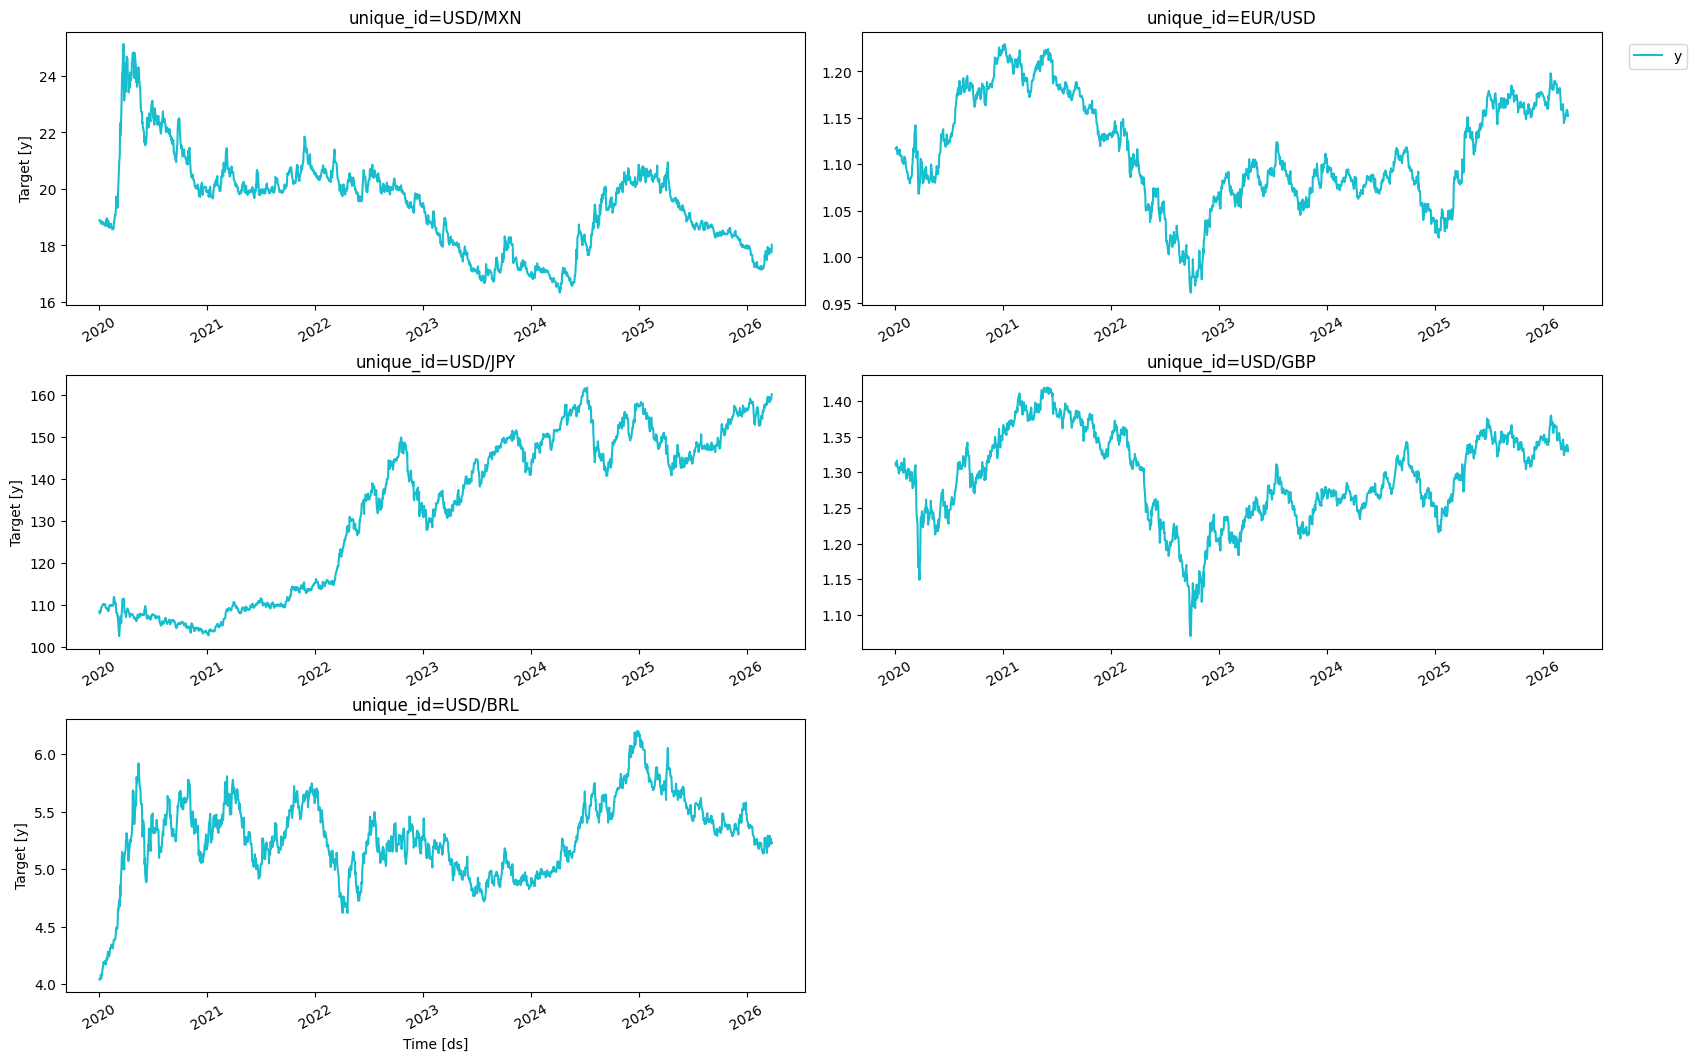

In [12]:
TimeCopilotForecaster.plot(df)

### Importar los modelos

Usaremos 6 modelos: 2 baselines estadísticos y 4 modelos fundacionales.

In [5]:
from timecopilot.models.foundation.chronos import Chronos
from timecopilot.models.foundation.moirai import Moirai
from timecopilot.models.foundation.timesfm import TimesFM
from timecopilot.models.stats import AutoARIMA, SeasonalNaive

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


### Crear el TimeCopilotForecaster

TimeCopilot unifica todos los modelos bajo una sola API. Los resultados de `forecast` y `cross_validation` se combinan automáticamente.

In [14]:
tcf = TimeCopilotForecaster(
    models=[
        AutoARIMA(),
        SeasonalNaive(),
        Chronos(repo_id="amazon/chronos-bolt-small"),
        Moirai(),
        TimesFM(repo_id="google/timesfm-2.0-500m-pytorch", alias="TimesFM-2.0"),
        TimesFM(repo_id="google/timesfm-2.5-200m-pytorch", alias="TimesFM-2.5"),
    ]
)

---

# Ejercicio 2: Validación Cruzada y Pronóstico

*~15 minutos*

1. Ejecutar `cross_validation` con `h=20` (≈1 mes de días hábiles), `level=[0, 20, 40, 60, 80]`
2. Graficar pronósticos superpuestos con valores reales
3. Inspeccionar `cv_df` — entender qué representan las columnas `-lo-` / `-hi-`
4. Visualmente: ¿qué intervalos de modelo lucen mejor calibrados?

### Ejecutar validación cruzada

Usamos `h=20` (aproximadamente 1 mes de días hábiles) y `level=[0, 20, 40, 60, 80]` para obtener intervalos de predicción a múltiples niveles de confianza. El nivel 0 corresponde al pronóstico puntual (mediana).

In [15]:
level = [0, 20, 40, 60, 80]
cv_df = tcf.cross_validation(df=df, h=20, freq="B", level=level)

0it [00:00, ?it/s]/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Processing dataframe with single process.
Finished preprocessing dataframe.


1it [01:50, 110.61s/it]


Finished forecasting.


100%|██████████| 1/1 [00:00<00:00,  1.40it/s]
1it [00:04,  4.15s/it]


### Graficar pronósticos vs valores reales

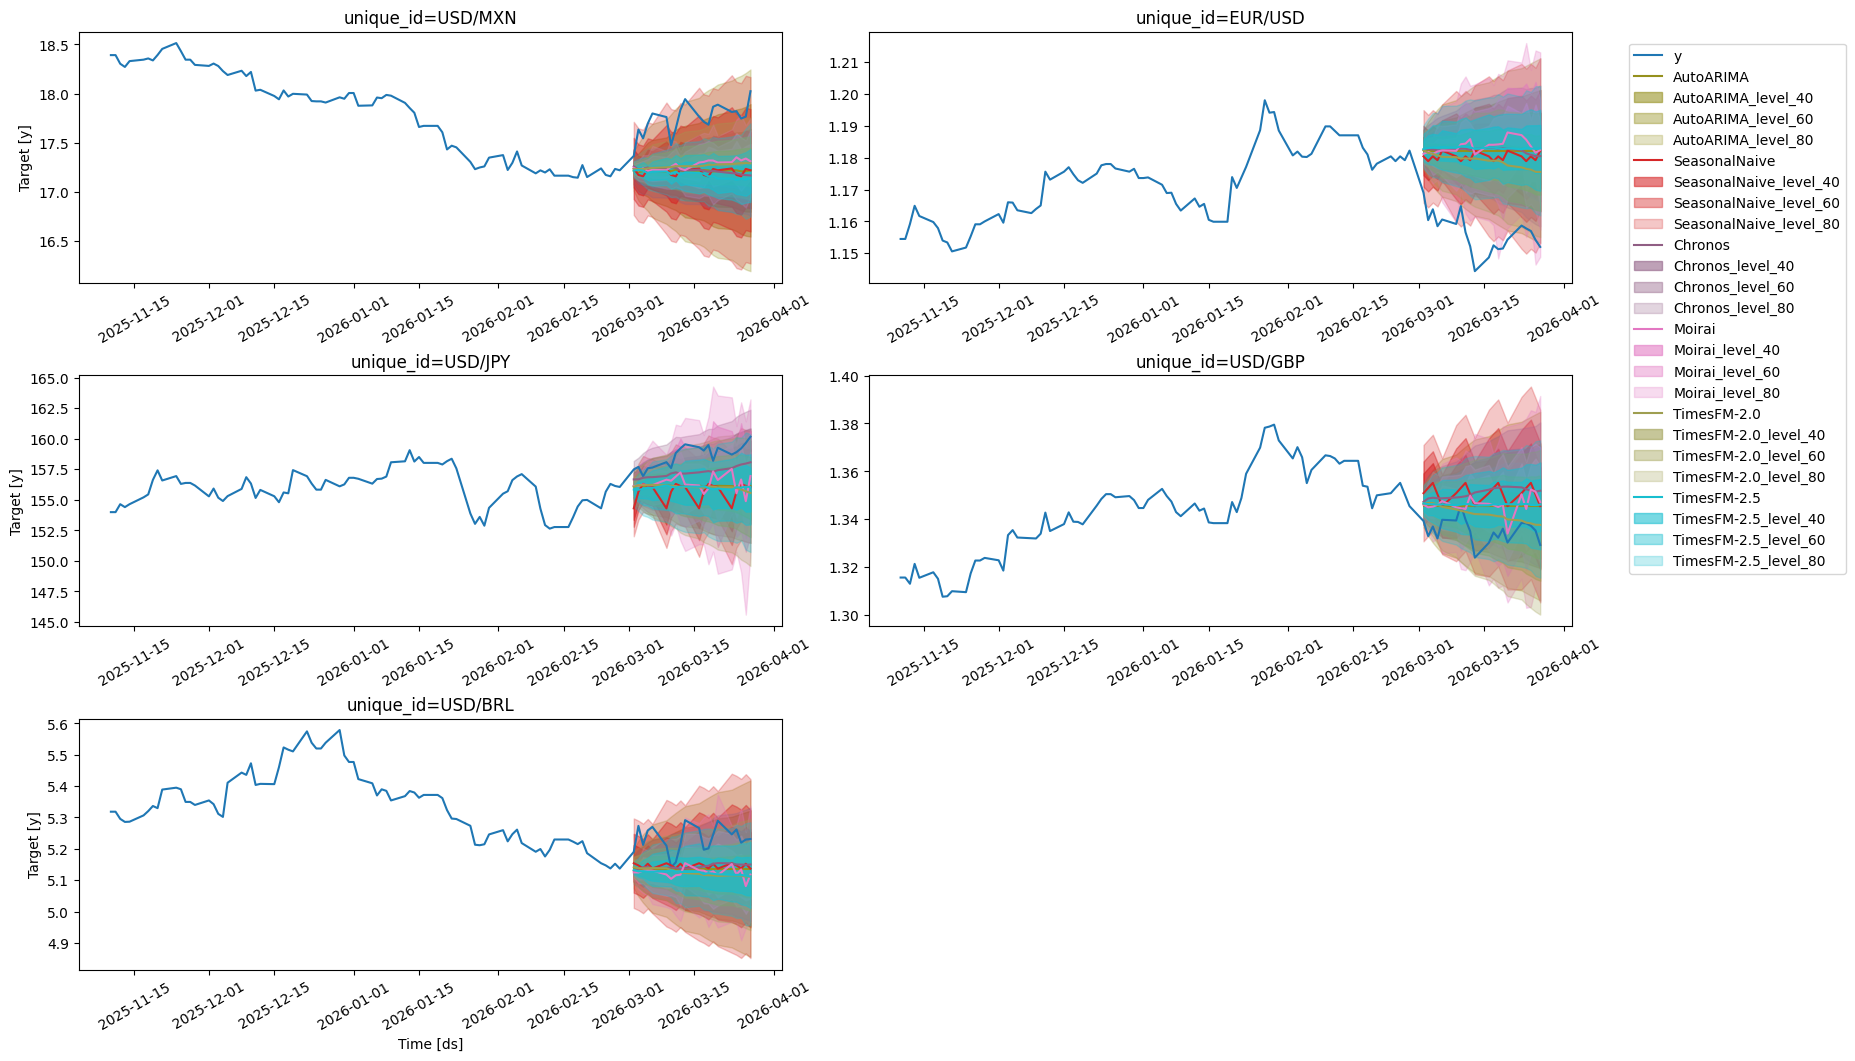

In [17]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[40, 60, 80], max_insample_length=100)

### Inspeccionar la estructura de salida

Las columnas `-lo-XX` y `-hi-XX` representan los límites inferior y superior del intervalo de predicción al nivel `XX`%.

In [18]:
cv_df.head()

,unique_id,ds,cutoff,y,AutoARIMA,AutoARIMA-lo-80,AutoARIMA-lo-60,AutoARIMA-lo-40,AutoARIMA-lo-20,AutoARIMA-lo-0,...,TimesFM-2.5-lo-0,TimesFM-2.5-hi-0,TimesFM-2.5-lo-20,TimesFM-2.5-hi-20,TimesFM-2.5-lo-40,TimesFM-2.5-hi-40,TimesFM-2.5-lo-60,TimesFM-2.5-hi-60,TimesFM-2.5-lo-80,TimesFM-2.5-hi-80
0,EUR/USD,2026-03-02,2026-02-27,1.1690,1.1822,1.175735,1.177954,1.179554,1.180922,1.1822,...,1.182711,1.182711,1.181699,1.184294,1.180562,1.185452,1.178831,1.187457,1.176573,1.190174
1,EUR/USD,2026-03-03,2026-02-27,1.1604,1.1822,1.173057,1.176195,1.178459,1.180392,1.1822,...,1.183012,1.183012,1.181623,1.184437,1.179839,1.186991,1.177904,1.188742,1.174922,1.192296
2,EUR/USD,2026-03-04,2026-02-27,1.1638,1.1822,1.171002,1.174846,1.177618,1.179986,1.1822,...,1.183140,1.183140,1.181903,1.185257,1.179961,1.187461,1.177729,1.190210,1.173836,1.194054
3,EUR/USD,2026-03-05,2026-02-27,1.1585,1.1822,1.169269,1.173708,1.176909,1.179644,1.1822,...,1.183162,1.183162,1.180874,1.185564,1.179111,1.187205,1.176795,1.190200,1.173687,1.194016
4,EUR/USD,2026-03-06,2026-02-27,1.1606,1.1822,1.167743,1.172706,1.176284,1.179342,1.1822,...,1.183287,1.183287,1.181709,1.186036,1.179061,1.188562,1.176216,1.191592,1.172370,1.196251


**Pregunta para discusión:** Observando las gráficas, ¿qué modelo parece tener los intervalos de predicción mejor calibrados? ¿Algún modelo muestra intervalos demasiado anchos o demasiado estrechos?

---

# Ejercicio 3: Análisis de Métricas

*~25 minutos — este es el ejercicio central*

1. Ejecutar `evaluate()` con MASE y Scaled CRPS
2. Rankear modelos por cada métrica de forma independiente
3. Identificar dónde se invierten los rankings — ¿qué modelos se benefician del CRPS?
4. Aplicar a banca: ¿cuándo la calidad del intervalo supera la precisión puntual?

### Importar utilidades de evaluación

In [19]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

### Evaluar con MASE y Scaled CRPS

- **MASE** (Mean Absolute Scaled Error): mide la precisión del pronóstico puntual relativa a un baseline naive. Valores < 1 significan que el modelo supera al naive.
- **Scaled CRPS** (Continuous Ranked Probability Score): mide la calidad probabilística — qué tan bien calibrados están los intervalos de predicción. Menor es mejor.

In [20]:
cutoff = cv_df["cutoff"].min()
train_df = df.query("ds <= @cutoff")

eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=train_df,
    metrics=[partial(mase, seasonality=5), scaled_crps],
    level=level,
)
eval_df.head()

,unique_id,metric,AutoARIMA,SeasonalNaive,Chronos,Moirai,TimesFM-2.0,TimesFM-2.5
0,EUR/USD,mase,3.010687,2.779858,3.022138,3.164644,2.631580,3.107470
1,USD/BRL,mase,1.107534,1.012563,1.030049,1.259849,1.254297,1.268611
2,USD/GBP,mase,0.897106,1.379620,1.373250,0.966182,0.626312,0.953263
3,USD/JPY,mase,1.906604,2.231135,1.030290,1.705320,1.968641,2.001833
4,USD/MXN,mase,2.084908,2.122777,2.077971,1.838063,1.889447,2.238040


### Ranking de modelos por métrica

In [22]:
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(by="scaled_crps").round(4)

metric,mase,scaled_crps
AutoARIMA,1.8014,0.0139
TimesFM-2.0,1.6741,0.0140
SeasonalNaive,1.9052,0.0143
Chronos,1.7067,0.0144
Moirai,1.7868,0.0145
TimesFM-2.5,1.9138,0.0161


### Discusión

**Precisión puntual (MASE)**
- Mejor predicción de la mediana
- Importa cuando: actúas directamente sobre el pronóstico puntual (ej. reposición de efectivo en cajeros)

**Calidad probabilística (CRPS)**
- Mejor incertidumbre calibrada
- Importa cuando: necesitas intervalos para gestión de riesgo (VaR, reservas, stress testing)

**Preguntas para el grupo:**
1. ¿Cuáles de sus modelos actuales reportan solo pronósticos puntuales? ¿Qué están dejando de lado?
2. Si un modelo tiene mejor CRPS pero peor MASE, ¿lo aceptaría su equipo? ¿Quién decide?
3. ¿Cómo validan actualmente la calibración de intervalos en sus pipelines?

### El costo de ignorar la incertidumbre

Supongamos que tu mesa de operaciones tiene una posición abierta en USD/MXN y necesita decidir cuánto capital reservar para cubrir el riesgo de tipo de cambio.

- El **mejor modelo por MASE** te dice: *"El tipo de cambio será 20.5 mañana"*.
- Pero **¿20.5 ± 0.1 o 20.5 ± 2.0?** La diferencia son millones en requerimientos de capital.

Si solo miras el pronóstico puntual, no tienes forma de distinguir entre un escenario de baja volatilidad y uno de alta volatilidad. **El MASE no te dice nada sobre esto.**

Podemos verificarlo empíricamente: si un modelo dice que su intervalo al 80% cubre el rango probable, **¿realmente captura el 80% de los valores observados?** Si no, tus reservas de capital están mal calculadas.

In [31]:
models = ["AutoARIMA", "SeasonalNaive", "Chronos", "Moirai", "TimesFM-2.0", "TimesFM-2.5"]
coverage = []
for m in models:
    lo, hi = f"{m}-lo-80", f"{m}-hi-80"
    covered = (
        (cv_df["y"] >= cv_df[lo]) & (cv_df["y"] <= cv_df[hi])
    ).groupby(cv_df["unique_id"]).mean()
    covered.name = m
    coverage.append(covered)

coverage_df = pd.concat(coverage, axis=1)
coverage_df.loc["Promedio"] = coverage_df.mean()
coverage_df = coverage_df.round(3)
coverage_df.style.applymap(
    lambda v: "background-color: #ffcccc" if isinstance(v, float) and v < 0.80 else ""
)

,AutoARIMA,SeasonalNaive,Chronos,Moirai,TimesFM-2.0,TimesFM-2.5
unique_id,,,,,,
EUR/USD,0.200000,0.300000,0.000000,0.200000,0.150000,0.000000
USD/BRL,0.950000,1.000000,0.750000,0.750000,0.700000,0.600000
USD/GBP,0.950000,0.950000,0.750000,0.800000,0.950000,0.850000
USD/JPY,0.800000,0.800000,1.000000,0.900000,0.700000,0.750000
USD/MXN,0.750000,0.900000,0.100000,0.100000,0.050000,0.000000
Promedio,0.730000,0.790000,0.520000,0.550000,0.510000,0.440000


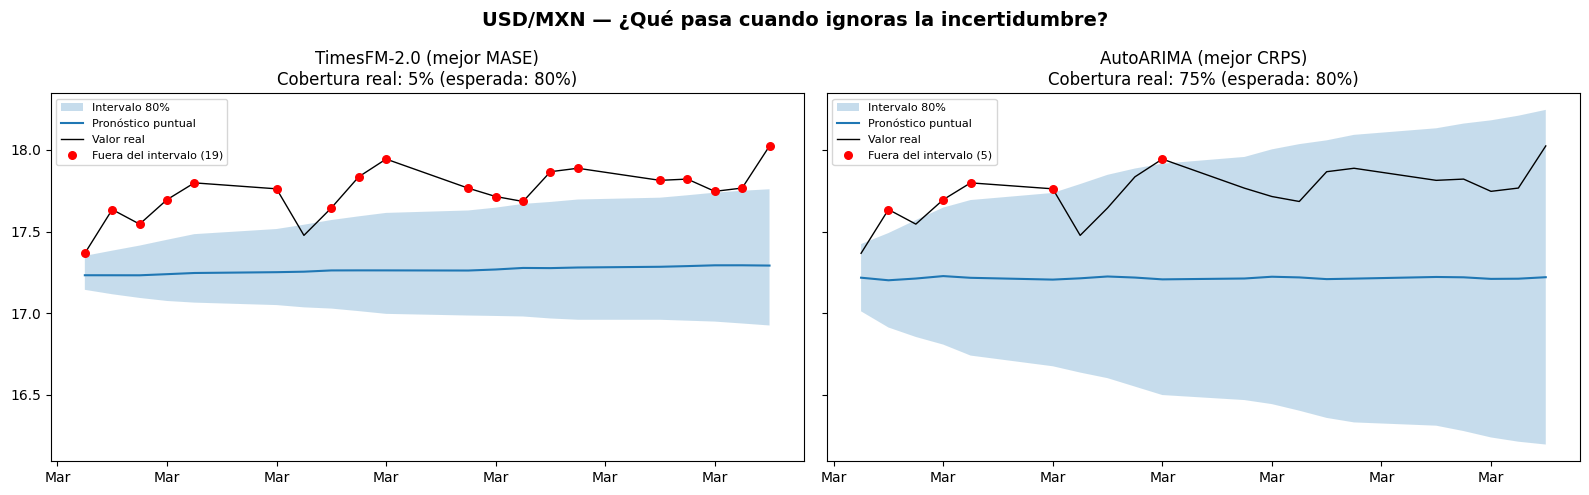

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pair = "USD/MXN"
pair_cv = cv_df.query("unique_id == @pair").sort_values("ds")

best_mase = eval_df.query("metric == 'mase'").drop(columns=["metric", "unique_id"]).mean().idxmin()
best_crps = eval_df.query("metric == 'scaled_crps'").drop(columns=["metric", "unique_id"]).mean().idxmin()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

for ax, model, label in zip(axes, [best_mase, best_crps], [f"{best_mase} (mejor MASE)", f"{best_crps} (mejor CRPS)"]):
    lo, hi = f"{model}-lo-80", f"{model}-hi-80"
    ds = pair_cv["ds"]
    y = pair_cv["y"]
    point = pair_cv[model]
    lo_vals = pair_cv[lo]
    hi_vals = pair_cv[hi]

    breach = (y < lo_vals) | (y > hi_vals)
    cov = (~breach).mean()

    ax.fill_between(ds, lo_vals, hi_vals, alpha=0.25, label="Intervalo 80%")
    ax.plot(ds, point, linewidth=1.5, label="Pronóstico puntual")
    ax.plot(ds, y, color="black", linewidth=1, label="Valor real")
    ax.scatter(ds[breach], y[breach], color="red", zorder=5, s=30, label=f"Fuera del intervalo ({breach.sum()})")
    ax.set_title(f"{label}\nCobertura real: {cov:.0%} (esperada: 80%)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.suptitle(f"{pair} — ¿Qué pasa cuando ignoras la incertidumbre?", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

### Implicaciones para banca

- **Under-hedging**: Si tu intervalo al 80% solo captura el 45% de los movimientos, tu VaR está subestimado. Estás reservando menos capital del que necesitas.
- **Riesgo regulatorio**: Los marcos de Basilea penalizan modelos cuyo backtesting muestra coberturas por debajo del nivel declarado. Intervalos mal calibrados generan excepciones regulatorias.
- **Eficiencia de capital**: Intervalos sobreconfiados (demasiado estrechos) significan menos capital reservado → pérdidas inesperadas. Intervalos demasiado anchos significan capital inmovilizado innecesariamente.

> **El MASE te dice *dónde* va el mercado. El CRPS te dice *cuánto puede moverse*.**

### Pronóstico hacia el futuro

La validación cruzada evalúa contra datos históricos. Ahora generamos pronósticos reales — los próximos 20 días hábiles (~1 mes) para cada par de divisas.

In [ ]:
fcst_df = tcf.forecast(df=df, h=20, freq="B", level=level)
fcst_df.head()

/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.htm

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.


100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


,unique_id,ds,AutoARIMA,AutoARIMA-lo-80,AutoARIMA-lo-60,AutoARIMA-lo-40,AutoARIMA-lo-20,AutoARIMA-lo-0,AutoARIMA-hi-0,AutoARIMA-hi-20,...,TimesFM-2.5-lo-0,TimesFM-2.5-hi-0,TimesFM-2.5-lo-20,TimesFM-2.5-hi-20,TimesFM-2.5-lo-40,TimesFM-2.5-hi-40,TimesFM-2.5-lo-60,TimesFM-2.5-hi-60,TimesFM-2.5-lo-80,TimesFM-2.5-hi-80
0,EUR/USD,2026-03-30,1.152,1.145532,1.147752,1.149353,1.150721,1.152,1.152,1.153279,...,1.151861,1.151861,1.150555,1.153151,1.149281,1.154196,1.147891,1.156149,1.145700,1.158392
1,EUR/USD,2026-03-31,1.152,1.142852,1.145993,1.148257,1.150192,1.152,1.152,1.153808,...,1.151382,1.151382,1.149866,1.152843,1.147764,1.155107,1.145923,1.156558,1.143418,1.160252
2,EUR/USD,2026-04-01,1.152,1.140796,1.144642,1.147416,1.149785,1.152,1.152,1.154215,...,1.151075,1.151075,1.149658,1.152885,1.147381,1.154861,1.145134,1.157842,1.141577,1.161629
3,EUR/USD,2026-04-02,1.152,1.139063,1.143504,1.146706,1.149443,1.152,1.152,1.154557,...,1.151187,1.151187,1.148493,1.153511,1.146865,1.155026,1.144447,1.158148,1.141293,1.162480
4,EUR/USD,2026-04-03,1.152,1.137536,1.142501,1.146082,1.149141,1.152,1.152,1.154859,...,1.151029,1.151029,1.149024,1.153546,1.146207,1.155901,1.143609,1.159502,1.139755,1.164213


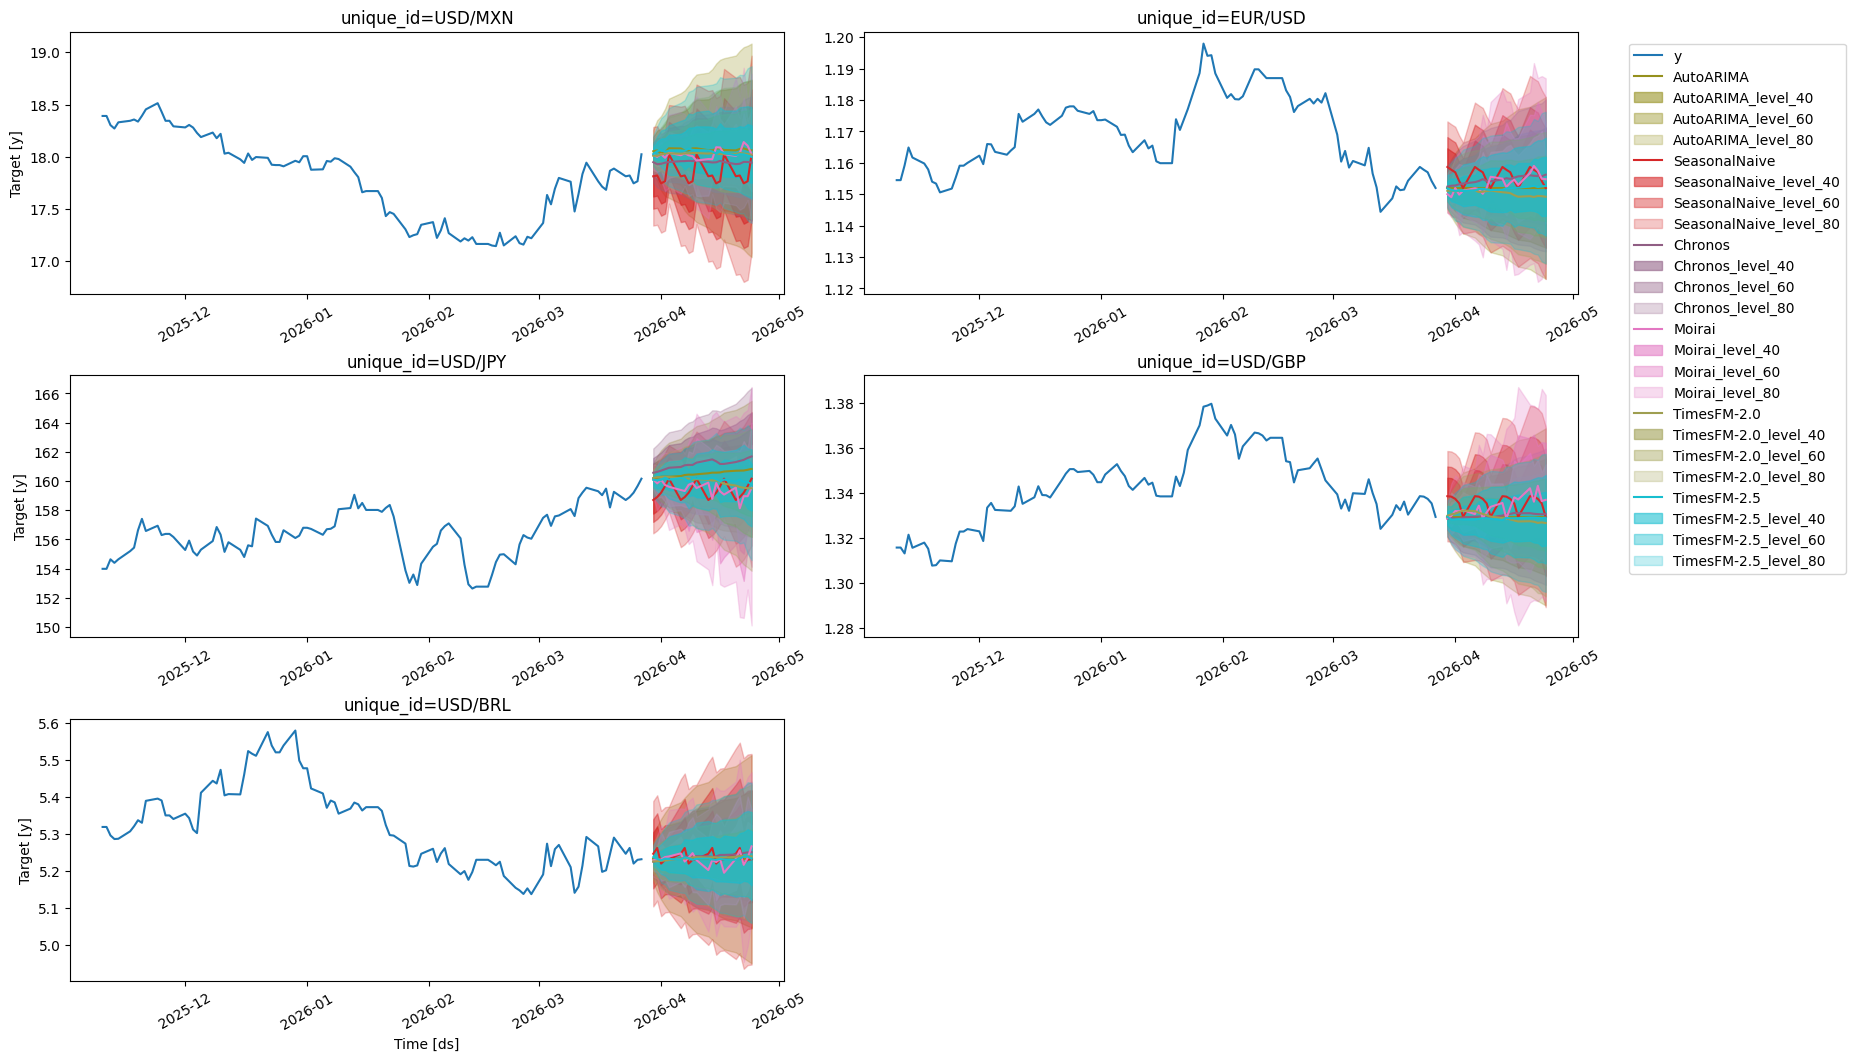

In [ ]:
tcf.plot(df, fcst_df, level=[40, 60, 80], max_insample_length=100)

---

# Ejercicio 4: Stress Test de Resultados

*~25 minutos*

Elige 2-3 de estos retos (o todos si el tiempo alcanza):

### A) Cambiar el horizonte

Re-ejecutar con `h=5` (1 semana) y `h=60` (3 meses). ¿Se mantienen los rankings? ¿Qué modelos se degradan en horizontes largos?

In [27]:
# h=5 (1 semana)
cv_df_h5 = tcf.cross_validation(df=df, h=5, freq="B", level=level)
cutoff_h5 = cv_df_h5["cutoff"].min()
eval_df_h5 = evaluate(
    cv_df_h5.drop(columns=["cutoff"]),
    train_df=df.query("ds <= @cutoff_h5"),
    metrics=[partial(mase, seasonality=5), scaled_crps],
    level=level,
)
print("=== h=5 (1 semana) ===")
display(
    eval_df_h5.groupby("metric")
    .mean(numeric_only=True)
    .T.sort_values(by="scaled_crps")
    .round(4)
)

0it [00:00, ?it/s]/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing dataframe with single process.
Finished preprocessing dataframe.


1it [00:09,  9.15s/it]


Finished forecasting.


100%|██████████| 1/1 [00:00<00:00,  1.36it/s]
1it [00:02,  2.48s/it]

=== h=5 (1 semana) ===


metric,mase,scaled_crps
Chronos,0.3680,0.0033
TimesFM-2.0,0.3967,0.0035
TimesFM-2.5,0.4446,0.0041
AutoARIMA,0.4549,0.0043
Moirai,0.4771,0.0045
SeasonalNaive,0.4464,0.0046


In [28]:
# h=60 (3 meses)
cv_df_h60 = tcf.cross_validation(df=df, h=60, freq="B", level=level)
cutoff_h60 = cv_df_h60["cutoff"].min()
eval_df_h60 = evaluate(
    cv_df_h60.drop(columns=["cutoff"]),
    train_df=df.query("ds <= @cutoff_h60"),
    metrics=[partial(mase, seasonality=5), scaled_crps],
    level=level,
)
print("=== h=60 (3 meses) ===")
display(
    eval_df_h60.groupby("metric")
    .mean(numeric_only=True)
    .T.sort_values(by="scaled_crps")
    .round(4)
)

0it [00:00, ?it/s]/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing dataframe with single process.
Finished preprocessing dataframe.


1it [00:08,  8.94s/it]


Finished forecasting.


100%|██████████| 1/1 [00:00<00:00,  1.26it/s]
1it [00:02,  2.50s/it]

=== h=60 (3 meses) ===


metric,mase,scaled_crps
TimesFM-2.5,1.3675,0.0121
TimesFM-2.0,1.4305,0.0129
Chronos,1.5127,0.0136
AutoARIMA,1.4168,0.0138
SeasonalNaive,1.6608,0.0160
Moirai,2.0349,0.0188


### B) Desglose por par de divisas

No promediar — revisar `eval_df` por `unique_id`. ¿Qué modelo domina en pares volátiles (USD/BRL, USD/MXN) vs pares más estables (EUR/USD)?

In [29]:
eval_by_series = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=train_df,
    metrics=[partial(mase, seasonality=5), scaled_crps],
    level=level,
    agg_fn=None,
)
eval_by_series.query("metric == 'mase'").set_index("unique_id").drop(columns=["metric"]).round(3)

,AutoARIMA,SeasonalNaive,Chronos,Moirai,TimesFM-2.0,TimesFM-2.5
unique_id,,,,,,
EUR/USD,3.011,2.780,3.022,3.165,2.632,3.107
USD/BRL,1.108,1.013,1.030,1.260,1.254,1.269
USD/GBP,0.897,1.380,1.373,0.966,0.626,0.953
USD/JPY,1.907,2.231,1.030,1.705,1.969,2.002
USD/MXN,2.085,2.123,2.078,1.838,1.889,2.238


In [30]:
eval_by_series.query("metric == 'scaled_crps'").set_index("unique_id").drop(columns=["metric"]).round(3)

,AutoARIMA,SeasonalNaive,Chronos,Moirai,TimesFM-2.0,TimesFM-2.5
unique_id,,,,,,
EUR/USD,0.018,0.016,0.019,0.018,0.016,0.020
USD/BRL,0.014,0.013,0.013,0.015,0.015,0.016
USD/GBP,0.006,0.008,0.008,0.006,0.005,0.006
USD/JPY,0.011,0.013,0.007,0.011,0.012,0.012
USD/MXN,0.021,0.021,0.025,0.022,0.022,0.027


### C) Probar con otros datos financieros

Probar con la curva de rendimiento de bonos del Tesoro de EE.UU. (Treasury yields a 2, 5, 10 y 30 años) o traer un CSV propio con columnas `unique_id`, `ds`, `y`.

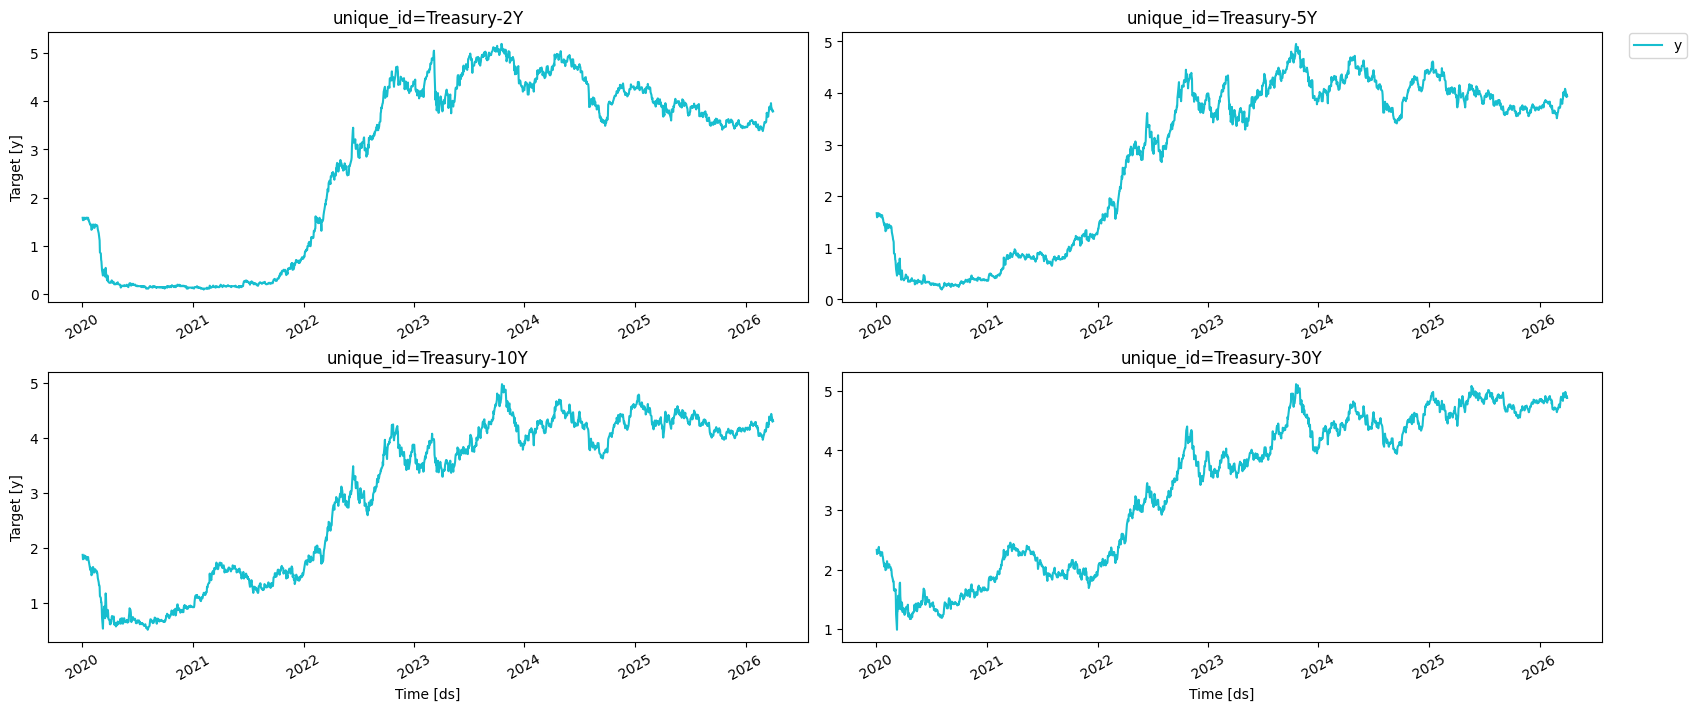

In [24]:
# Treasury yields (curva de rendimiento)
treasury_series = {"Treasury-2Y": "DGS2", "Treasury-5Y": "DGS5", "Treasury-10Y": "DGS10", "Treasury-30Y": "DGS30"}
treasury_dfs = []
for name, sid in treasury_series.items():
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}&cosd=2020-01-01"
    tmp = pd.read_csv(url, parse_dates=["observation_date"], na_values=["."])
    tmp = tmp.rename(columns={"observation_date": "ds", sid: "y"})
    tmp = tmp.set_index("ds").asfreq("B").ffill().dropna().reset_index()
    tmp["unique_id"] = name
    treasury_dfs.append(tmp)
treasury_df = pd.concat(treasury_dfs, ignore_index=True)[["unique_id", "ds", "y"]]

TimeCopilotForecaster.plot(treasury_df)

# treasury_cv = tcf.cross_validation(df=treasury_df, h=20, freq="B", level=level)
# tcf.plot(treasury_df, treasury_cv.drop(columns=["cutoff", "y"]), level=[40, 60, 80])

### D) Agregar más métricas

Importar `smape` y `rmse` de `utilsforecast.losses`. ¿Cambia el ranking otra vez? ¿Qué métrica es más estable?

In [26]:
from utilsforecast.losses import rmse, smape

eval_df_extended = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=train_df,
    metrics=[partial(mase, seasonality=5), scaled_crps, smape, rmse],
    level=level,
)
eval_df_extended.groupby("metric").mean(numeric_only=True).T.round(4)

metric,mase,rmse,scaled_crps,smape
AutoARIMA,1.8014,0.6686,0.0139,0.0094
SeasonalNaive,1.9052,0.7604,0.0143,0.0098
Chronos,1.7067,0.4353,0.0144,0.0089
Moirai,1.7868,0.6278,0.0145,0.0092
TimesFM-2.0,1.6741,0.6839,0.0140,0.0089
TimesFM-2.5,1.9138,0.7012,0.0161,0.0100


---

# Conclusiones

## Framework de Selección de Modelos

| Tu prioridad | Optimizar para | Ejemplo en banca |
|---|---|---|
| Pronóstico puntual insesgado | MASE, RMSE, SMAPE | Reposición de efectivo, planificación de demanda |
| Intervalos calibrados | Scaled CRPS, cobertura | VaR, reservas, stress testing |

**Ninguna métrica cuenta toda la historia.** Define tu función de pérdida *antes* de hacer benchmark — no después.

## Antes de Poner en Producción

Lo que no cubrimos hoy pero necesitarán responder:

- **Latencia de inferencia**: Los modelos fundacionales son mejores pero más lentos que AutoARIMA. ¿Cómo ajustamos procesos para hacerlos viables con el target de ventanas de servicio?
- **Gobernanza de modelos**: Pre-entrenados con datos externos — ¿cómo trata su equipo de MRM el riesgo de modelos de terceros?
- **Explicabilidad**: Los coeficientes de ARIMA son auditables. ¿Cómo explicamos un pronóstico de Chronos a un regulador?
- **Fine-tuning vs zero-shot**: Estos resultados son zero-shot. El fine-tuning con datos de su dominio puede cerrar o ampliar la brecha.
- **Estrategias de ensamble**: Combinar el mejor modelo por MASE con el mejor por CRPS — obtener calidad puntual y de intervalos.

## Takeaways

1. Los modelos fundacionales superan a los baselines estadísticos en este dataset — pero **no todos, y no en todas las métricas**.
2. La elección de métrica es una **decisión de negocio**, no estadística. Defínela antes del benchmark.
3. El análisis por serie importa más que los promedios agregados — una serie mala puede dominar todo.
4. Zero-shot es el piso, no el techo. Fine-tuning y ensambles son el siguiente paso.

---

Más tutoriales y documentación: [timecopilot.dev/examples](https://timecopilot.dev/examples)

---

# Bonus: TimeCopilot Agent, Forecasting en lenguaje natural

Hasta ahora usamos el **Forecaster** para controlar manualmente qué modelos ejecutar y cómo evaluarlos. Pero TimeCopilot también incluye un **Agente** que orquesta todo el pipeline automáticamente: analiza las series, selecciona modelos, ejecuta validación cruzada y genera pronósticos — todo desde una pregunta en lenguaje natural.

El agente usa un LLM (como GPT-4o) como motor de razonamiento para decidir qué hacer en cada paso.

In [9]:
import nest_asyncio

nest_asyncio.apply()

### Inicializar el agente

In [10]:
from timecopilot import TimeCopilot

tc = TimeCopilot(
    llm="openai:gpt-4o",
    forecasters=[
        AutoARIMA(),
        SeasonalNaive(),
        Chronos(repo_id="amazon/chronos-bolt-small"),
        Moirai(),
        TimesFM(repo_id="google/timesfm-2.0-500m-pytorch", alias="TimesFM-2.0"),
    ]
)

### Analizar con una pregunta en lenguaje natural

El agente decide automáticamente qué modelos usar, ejecuta la validación cruzada y genera el pronóstico. Solo necesitas una pregunta.

In [15]:
result = tc.analyze(
    df=df,
    freq="B",
    query="¿Cuál será el tipo de cambio USD/MXN en los próximos 20 días hábiles?",
)
print(result.output.prettify())

0it [00:00, ?it/s]/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
/Users/azul/projects/TimeCopilot/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest

╭───────────────────────────────────────────── TimeCopilot Forecast ──────────────────────────────────────────────╮
│ Chronos forecast analysis                                                                                       │
│ Better than Seasonal Naive                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

1. Time Series Analysis

             Time Series Features              
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Feature  ┃ Value                            ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Features │ Available in analysis text below │
└──────────┴──────────────────────────────────┘

╭─────────────────────────────────────────────── Feature Analysis ────────────────────────────────────────────────╮
│ The USD/MXN time series data demonstrates a very strong trend with a trend component close to 1. It indicates a │
│ slightly seasonal pattern with some seasonal strength, as highlighted by the seasonal_strength parameter. The   │
│ strong autocorrelations over lags suggest the data is non-stationary, as confirmed by the unit root test        │
│ (unitroot_pp). The series requires differencing to achieve stationarity, with significant autocorrelation at    │
│ lag 1.                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

4. Anomaly Detection

╭─────────────────────────────────────────────── Anomaly Detection ───────────────────────────────────────────────╮
│ The anomaly detection conducted with the Chronos model identified 470 anomalies at a 95% confidence level,      │
│ representing a 5.8% anomaly rate in the dataset. Notable clusters were detected around early March 2020,        │
│ coinciding with significant market turmoil possibly linked to globally relevant events. This suggests these     │
│ anomalies are likely related to external shocks. Understanding these can support better risk management and     │
│ prediction adjustments in future models.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

5. Additional Information

╭─────────────────────────────────────────────── Response to Query ───────────────────────────────────────────────╮
│ The predicted USD/MXN exchange rate over the next 20 business days suggests minor fluctuations around           │
│ approximately 17.95 MXN/USD, using the Chronos forecasting model.                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

None


### Hacer preguntas de seguimiento

Después del análisis, el agente mantiene el contexto. Puedes preguntar sobre los resultados como en una conversación.

In [16]:
answer = tc.query("¿Qué modelo tuvo el mejor desempeño y por qué?")
print(answer.output)

El modelo que tuvo el mejor desempeño fue **Chronos** con la puntuación MASE más baja, registrada como **1.7067**. Esta puntuación indica que Chronos tuvo, en promedio, menos error proporcional en comparación con los otros modelos. Un menor valor de MASE significa un mejor ajuste a los datos históricos y una mejor capacidad predictiva en el contexto evaluado.

Es importante mencionar que la MASE (Mean Absolute Scaled Error) es una métrica de error que compara el error absoluto medio del modelo con el error absoluto medio de un modelo de referencia, permitiendo evaluar la precisión de diferentes modelos de previsión en una escala estándar donde valores menores de 1 indican que el modelo supera al modelo de referencia simple.

En resumen, Chronos superó a los otros modelos (AutoARIMA con MASE de 1.8014 y SeasonalNaive con MASE de 1.9052) al tener el menor error de predicción según la métrica MASE.


In [17]:
answer = tc.query("¿Cuál es el riesgo de usar solo pronósticos puntuales para tomar decisiones de cobertura cambiaria?")
print(answer.output)

El uso exclusivo de pronósticos puntuales para la toma de decisiones de cobertura cambiaria presenta varios riesgos:

1. **Falta de Incertidumbre y Rango de Error**: Los pronósticos puntuales no capturan la incertidumbre inherente en las previsiones de tipo de cambio. No proporcionan un rango de posibles valores futuros, lo que significa que no se tiene una idea clara de qué tan seguro o incierto es el pronóstico. Esto puede llevar a sobreconfianza en el pronóstico y a una subestimación del riesgo.

2. **Volatilidad del Mercado**: Los mercados de divisas pueden ser altamente volátiles y sensibles a eventos macroeconómicos globales, noticias geopolíticas u otros factores inesperados. Un pronóstico puntual no considera los posibles cambios bruscos o choques que pueden ocurrir, lo que podría resultar en grandes desviaciones del pronóstico.

3. **Ausencia de Contexto para la Toma de Decisiones**: Sin considerar escenarios alternativos o la variabilidad esperada, es difícil hacer una evalua

### Prueba tus propias preguntas

El agente puede responder sobre tendencias, anomalías, comparación de modelos, o cualquier aspecto de las series de tiempo.

In [ ]:
# answer = tc.query("tu pregunta aquí")
# print(answer.output)